In [5]:
import numpy as np
import pandas as pd
from scipy.special import logsumexp
from scipy.stats import spearmanr
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from multiprocessing import Pool
import matplotlib.pyplot as plt
import seaborn as sns
# import networkx as nx
from joblib import Parallel, delayed
from adjustText import adjust_text

import sys, os
codes_dir = os.path.join(os.getcwd(), 'codes')   
if codes_dir not in sys.path:
    sys.path.insert(0, codes_dir)  


In [6]:

full_df = pd.read_csv('all_action_rt_ana.csv')
for i, col in enumerate(full_df.columns):
    print(f"{i}: {col}", end = ';  ')

in_game_action = ['Undo', 'Restart', 'Up', 'Down', 'Left', 'Right','Success', 'Defeat']
move_action = ['Up', 'Down', 'Left', 'Right']
game_action = ['Undo', 'Restart', 'Up', 'Down', 'Left', 'Right']
opposite = {'Up': 'Down', 'Down': 'Up', 'Left': 'Right', 'Right': 'Left'}
init = {'Up': '↑', 'Down': '↓', 'Left': '←', 'Right': '→', 'Undo': '↶', 'Restart': '↻',
        'Success': '✓', 'Defeat': 'x', 'Stop': '■', 'Start': '▶', 'Login': 'I', 'Logout': 'O'}


0: Pid;  1: Uid;  2: Prior;  3: Cond;  4: Level;  5: Map;  6: Count_Global;  7: Count;  8: Timestamp;  9: Action;  10: Action_Before;  11: Action_After;  12: Before;  13: After;  14: Act;  15: Outcome;  16: pre_num_exist_rules;  17: pre_has_WIN_rule;  18: pre_has_DEFEAT_rule;  19: pre_has_PUSH_rule;  20: pre_has_STOP_rule;  21: pre_has_YOU_rule;  22: pre_has_REGULAR_rule;  23: pre_num_reach_objects;  24: pre_change_reach_objects;  25: pre_exist_WIN_object;  26: pre_reach_WIN_object;  27: pre_exist_DEFEAT_object;  28: pre_reach_DEFEAT_object;  29: pre_exist_PUSH_object;  30: pre_reach_PUSH_object;  31: pre_exist_STOP_object;  32: pre_reach_STOP_object;  33: pre_exist_TEXT_object;  34: pre_reach_TEXT_object;  35: pre_exist_REGULAR_object;  36: pre_reach_REGULAR_object;  37: cha_num_form_rules;  38: cha_num_break_rules;  39: cha_form_rules;  40: cha_break_rules;  41: cha_form_WIN_rule;  42: cha_break_WIN_rule;  43: cha_form_DEFEAT_rule;  44: cha_break_DEFEAT_rule;  45: cha_form_PUSH_rule;

In [3]:
full_df.groupby('Map').Before.count()

Map
base        321398
break        69471
helper      125252
intro        25680
make         95483
maze         39675
target      558177
tutorial     31685
Name: Before, dtype: int64

### 变量解释
- Pid(16): profilic ID for each block
- Uid(int): use profilic_id_to_uid.json to map Pid to int
- Prior(cat) & Cond(cat): 5 * 2 = 10 condition
- Level(int) & Map(cat): index(0, 1, 2, 3, 4, -1) and name of each puzzle
- Count_Global(int) & Count(int): Block and Level index for action
- TimeStamp(float): time from start
- Action(Act): 12, Login, Start, Stop, Logout, Success, Defeat, Up Down Left Right, Undo, Restart
- Act(Str): 12，I ↑ ↓ ← → ↶ ↻ ✓ x ■ ▶ O
- Action_Before(Act), Action_Afte(Act): Action before & after current action
- Before(float), After(float): RT before & afrer current action


In [11]:
full_df.head(5)


,Pid,Uid,Prior,Cond,Level,Map,Count_Global,Count,Timestamp,Action,...,inter_direct_DEFEAT_inter,inter_indirect_DEFEAT_inter,inter_direct_PUSH_inter,inter_indirect_PUSH_inter,inter_direct_STOP_inter,inter_indirect_STOP_inter,inter_direct_TEXT_inter,inter_indirect_TEXT_inter,inter_direct_REGULAR_inter,inter_indirect_REGULAR_inter
0,57e4355291b7fc0001494db8,110,none,near,0,intro,1,0,18.120,Start,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,57e4355291b7fc0001494db8,110,none,near,0,intro,2,1,26.787,Right,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,57e4355291b7fc0001494db8,110,none,near,0,intro,3,2,27.103,Down,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,57e4355291b7fc0001494db8,110,none,near,0,intro,4,3,27.354,Right,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,57e4355291b7fc0001494db8,110,none,near,0,intro,5,4,27.987,Right,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



## Model-Free Analysis
- Action of Interest: Up Down Left Right Undo Restart
- Transition(B) of Interest: Start/Move/Undo/Restart -> Move, Move(❌)/Defeat -> Undo, Start(❌)/Move/Defeat/Undo -> Restart
- Transition(A) of Interest: Move -> Move/Undo/Restart/Success/Defeat/Stop(❌), Undo -> Move/Restart/Stop, Restart -> Move/Stop/Restart

In [4]:
# 筛选：有效动作（上下左右撤销重开），
AoI = full_df.query('Action in @in_game_action and Uid != -1').copy()
AoI.loc[:, 'Before'] = AoI.Before.clip(0.25, float('inf')).round(3)
AoI.loc[:, 'After'] = AoI.After.clip(0.25, float('inf')).round(3)
AoI.loc[:, 'Before_'] = AoI.Before.clip(0.25, 20).round(3)
AoI.loc[:, 'After_'] = AoI.After.clip(0.25, 20).round(3)
AoI.loc[:, 'LogBefore'] = np.log(AoI.Before * 4)
AoI.loc[:, 'LogAfter'] = np.log(AoI.After * 4)
AoI_base = AoI.query('Map == "base"').copy()

### Distribution of RT

Quantile of RT: 
     Before  After
0.0   0.250  0.250
0.1   0.250  0.250
0.2   0.250  0.250
0.3   0.255  0.255
0.4   0.266  0.266
0.5   0.267  0.267
0.6   0.286  0.286
0.7   0.350  0.350
0.8   0.450  0.450
0.9   0.734  0.735


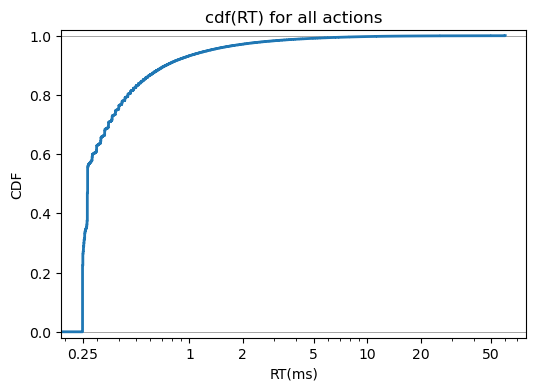

In [22]:
# RT 单变量的分布
# model as RT = 0.25(baseline) + residual(time of thinking)
_, ax = plt.subplots(1, 1, figsize=(6,4))
ticks = [0.25, 1, 2, 5, 10, 20, 50]
ax.set(xlabel = 'RT(ms)', ylabel = 'CDF', title = 'cdf(RT) for all actions', xscale = 'log', xticks = ticks, xticklabels = ticks,  ylim = (-0.02, 1.02))
[ax.axhline(x, color = 'grey', linewidth = 0.5) for x in [0, 1]]
sns.ecdfplot(data=AoI.Before.clip(0.25, 60), linewidth=2, ax = ax)
# sns.ecdfplot(data=AoI.groupby('Uid').Before.min(), linewidth=2, ax = ax)
print(f'Quantile of RT: \n{AoI[['Before', 'After']].quantile(np.arange(0.0, 1.0, 0.1))}')

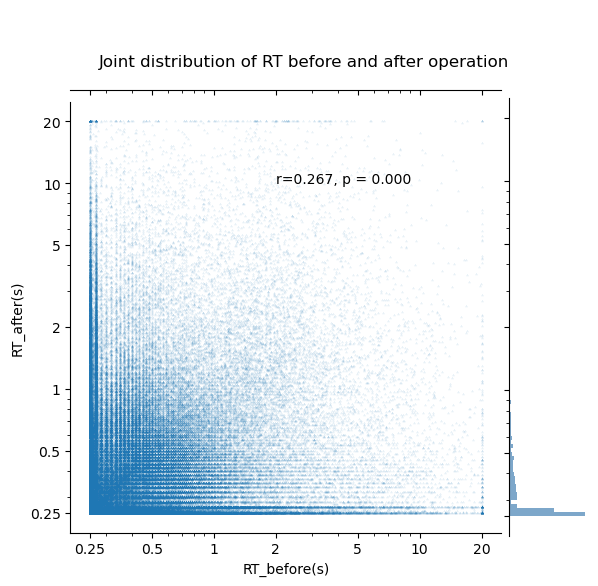

In [60]:
# RT 联合分布（带边缘分布）

g = sns.JointGrid(data=AoI_base, x='Before_', y='After_', height=6, ratio=5, space=0.1)
g.plot_joint(plt.scatter, marker = '1', s=1, alpha=0.1)

bins_y = np.logspace(np.log10(AoI_base.After_.min()), np.log10(AoI_base.After_.max()), 100)
g.ax_marg_y.hist(AoI_base.After_, bins=bins_y, orientation='horizontal', alpha=0.7, color='steelblue')

rho, pvalue = spearmanr(AoI_base.Before_, AoI_base.After_)
tick_values = [0.25, 0.5, 1, 2, 5, 10, 20]
g.ax_joint.set(xscale='log', yscale='log', aspect = 'equal',    
               xticks=tick_values, xticklabels=tick_values,
               yticks=tick_values, yticklabels=tick_values,
               xlabel='RT_before(s)', ylabel='RT_after(s)')
g.fig.suptitle('Joint distribution of RT before and after operation', y = 0.9)
g.ax_joint.text(2, 10, f'r={rho:.3f}, p = {pvalue:.3f}',)
plt.savefig('RT_joint_distribution.png', dpi=600, bbox_inches='tight')
plt.show()

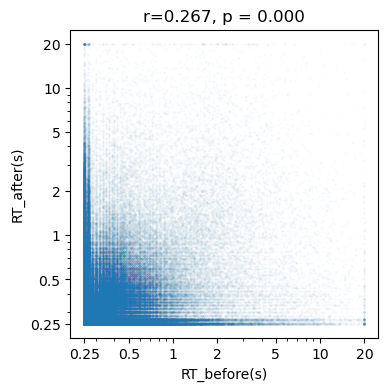

In [97]:
# RT 联合分布
fig, ax = plt.subplots(figsize = (6, 4))
ax.scatter(AoI_base.Before_, AoI_base.After_, s = 0.1, alpha = 0.05)
rho, pvalue = spearmanr(AoI_base.Before_, AoI_base.After_)
ax.set(xscale = 'log', yscale = 'log', title = f'r={rho:.3f}, p = {pvalue:.3f}', aspect = 'equal',
        xticks = tick_values, xticklabels = tick_values, 
        yticks = tick_values, yticklabels = tick_values, 
        xlabel = 'RT_before(s)', ylabel = 'RT_after(s)')
plt.show()


C:\Users\asus\AppData\Local\Temp\ipykernel_40948\3408203848.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  decile_bounds = AoI.groupby('Before_Decile')['Before'].agg(['min', 'max']).applymap(lambda x: f'{x:.3f}')


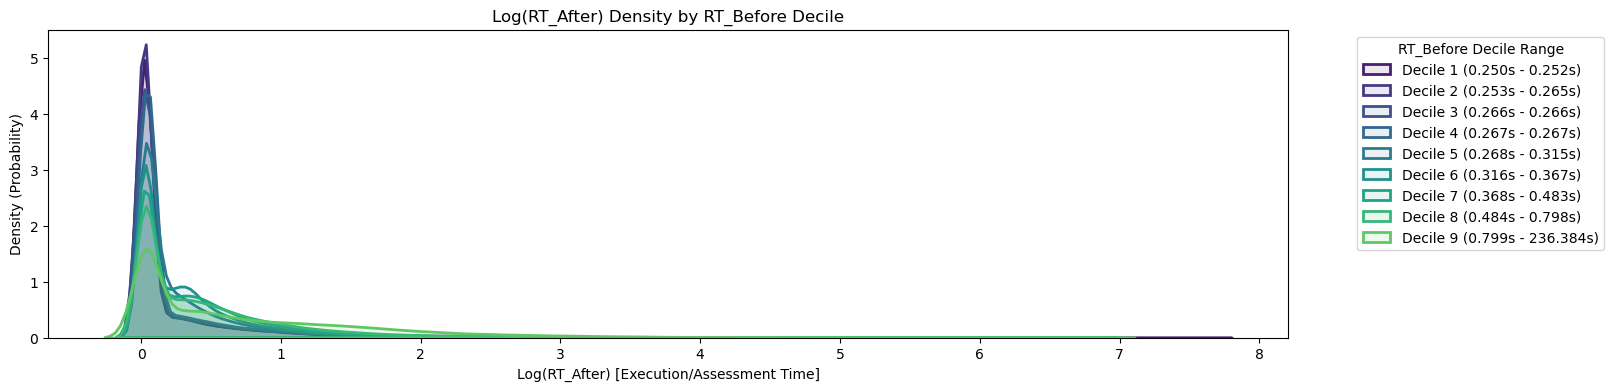

In [ ]:
N = 11
AoI.loc[:, 'Before_Decile'] = pd.qcut(AoI['Before'],q=N,labels=False, duplicates='drop')
decile_bounds = AoI.groupby('Before_Decile')['Before'].agg(['min', 'max']).applymap(lambda x: f'{x:.3f}')
fig, ax = plt.subplots(1, 1, figsize = (16, 4))
colors = sns.color_palette("viridis", n_colors=N)
for i in sorted(AoI['Before_Decile'].unique()):
    subset = AoI[AoI['Before_Decile'] == i]
    label = (f'Decile {i+1} ({decile_bounds.loc[i, "min"]}s - {decile_bounds.loc[i, "max"]}s)')
    sns.kdeplot(data=subset,x='LogAfter',ax=ax,label=label,color=colors[i],
        linewidth=2,fill=True, alpha=0.1)
ax.set(title = 'Log(RT_After) Density by RT_Before Decile', xlabel = 'Log(RT_After) [Execution/Assessment Time]', ylabel = 'Density (Probability)')
ax.legend(title='RT_Before Decile Range', bbox_to_anchor=(1.05, 1), loc='upper left')

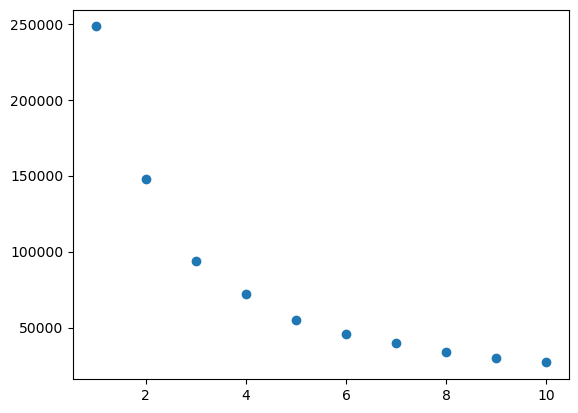

In [94]:
K_max, wcss = 10, []
X = AoI_base[['LogBefore', 'LogAfter']].copy()
for k in range(1, 1 + K_max):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.scatter(np.arange(1, K_max+1), wcss)

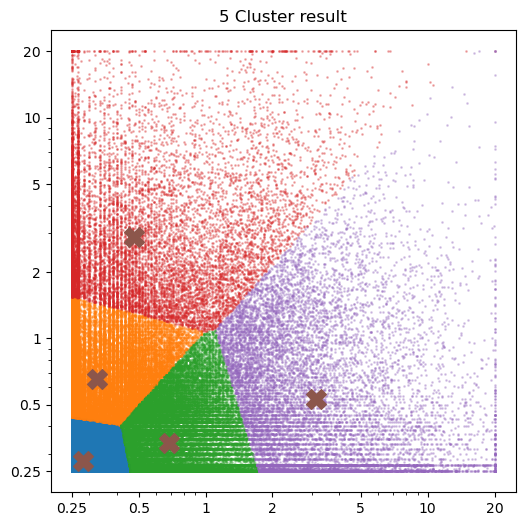

In [102]:
K = 5
kmeans = KMeans(n_clusters=K)
AoI_base.loc[:, 'RT_Cluster'] = kmeans.fit_predict(X)
cluster_centers = np.exp(kmeans.cluster_centers_)/4
center_df = pd.DataFrame(cluster_centers, columns=['LogBefore_Center', 'LogAfter_Center'])

fig, ax = plt.subplots(1, 1, figsize = (6, 6))
for cluster_id in range(K):
    subset = AoI_base[AoI_base['RT_Cluster'] == cluster_id]
    ax.scatter(subset['Before_'], subset['After_'],s=1,alpha=0.3,
        label=f'Cluster {cluster_id} (n={len(subset):,})')
ax.scatter(center_df['LogBefore_Center'],center_df['LogAfter_Center'],s=200,marker='X')

ax.set(xscale = 'log', yscale = 'log', xticks = tick_values, xticklabels=tick_values, 
       yticks = tick_values, yticklabels = tick_values, title = f'{K} Cluster result')
plt.show()

### RT~Step

In [ ]:
# RT ~ Step Count
# time of thinking = bsic wave(exp decrease) + residual(planning bump)
map_data = AoI.groupby(['Map', 'Uid']).Count.max().groupby('Map')
def grouped_step_rt(map, steps, ax = None):
    ax = ax if ax else  plt.subplots(1, 1, figsize=(12, 3))[1]
    steps = map_data.min().clip(40, 100)[map]
    grouped_data = AoI.query('Map == @map and Count <= @steps').groupby('Count').Before
    m, se = grouped_data.mean(), grouped_data.std() / np.sqrt(grouped_data.count())
    lower, upper = grouped_data.quantile(0.05), grouped_data.quantile(0.95)
    ax.plot(m.index, m, linewidth = 2)
    ax.fill_between(m.index, lower, upper, alpha = 0.2)
    ax.set(xlabel = 'Step Count', ylabel =  'RT(s)', title = f'First {steps} step for Level [{map}]', ylim = (0, 10), xticks = np.arange(1, steps, 2))
    plt.axhline(0.25, color = 'grey', linewidth = 0.5)
    plt.axvline(min(map_data.min()[map], steps), color = 'grey', linewidth = 0.5)
[grouped_step_rt(map, 40) for map in ['intro', 'tutorial', 'base', 'target', 'maze', 'make', 'break', 'helper']]
plt.show()


In [31]:
map_data.aggregate(['min', 'median', 'max', 'mean', 'std'])

,min,median,max,mean,std
Map,,,,,
base,34,208.0,1413,286.409660,238.987851
break,51,328.0,1013,319.105991,211.720734
helper,17,162.0,1389,258.730290,272.894041
intro,7,12.5,795,21.969589,43.673352
make,149,397.0,1318,473.875622,268.227887
maze,76,123.0,1278,180.981651,173.633704
target,26,445.5,1506,497.923077,362.804906
tutorial,11,19.0,359,27.340787,29.400564


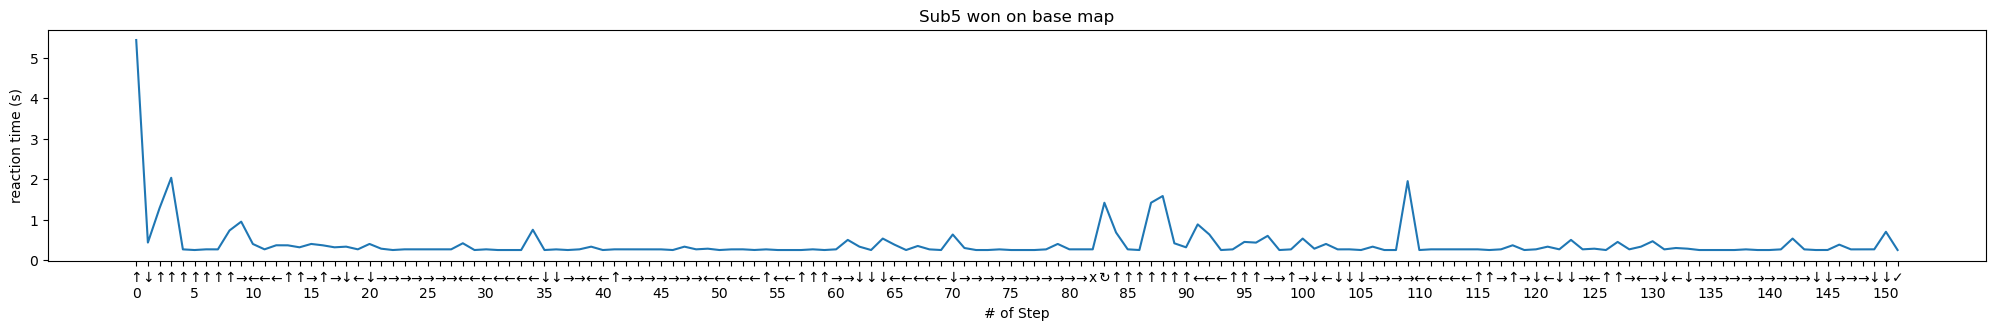

In [105]:
def norm(rts):
    return (rts - 0.25) / (rts.max() - 0.25)
def single_step_rt(uid, map, steps, ax = None):
    ax = ax if ax else plt.subplots(1, 1, figsize = (max(steps // 8, 20), 3))[1]
    selected = AoI.query('Uid == @uid and Map == @map and Count <= @steps')
    ax.plot(np.arange(len(selected)), selected.Before)
    outcome = 'won' if selected.Action.iloc[-1] == 'Success' else 'lost'
    ax.set(xlabel = '# of Step', ylabel = 'reaction time (s)', title = f'Sub{uid} {outcome} on {map} map',# yscale = 'log',
            xticks = np.arange(len(selected)), xticklabels = [f"{a}\n{c}"if c % 5 == 0 else f"{a}" for c, a in enumerate(selected.Act)])
    return selected.Before
rts0 = single_step_rt(5, 'base', 200)



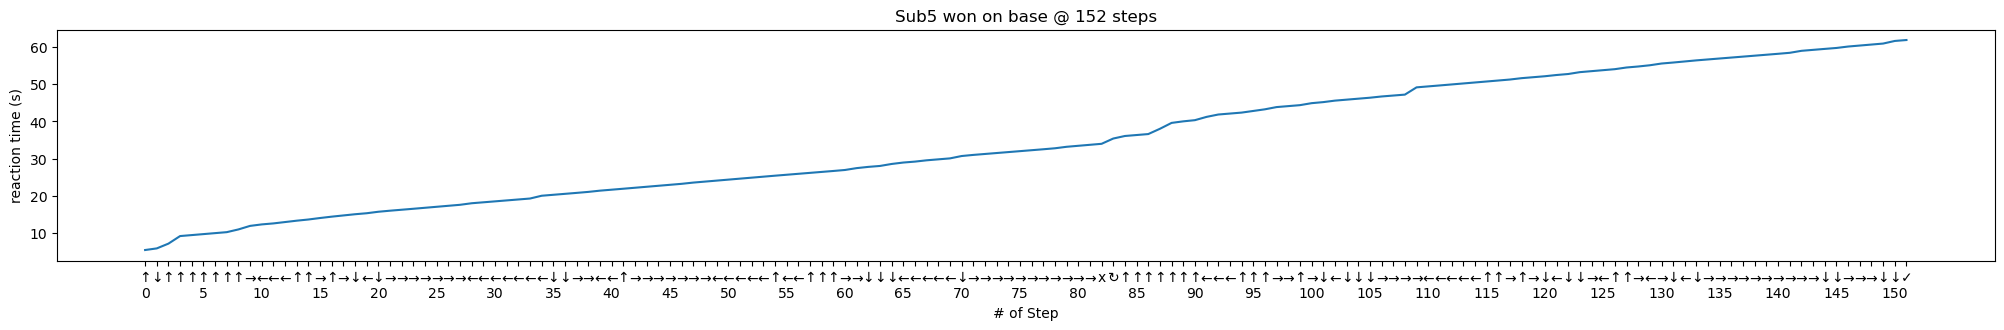

In [108]:
def single_step_rt_diff(uid, map, steps):
    selected = AoI.query('Uid == @uid and Map == @map and Count <= @steps')
    _, ax = plt.subplots(1, 1, figsize = (max(steps // 8, 20), 3))
    ax.plot(np.arange(len(selected)), selected.Before.cumsum())
    outcome = 'won' if selected.Action.iloc[-1] == 'Success' else 'lost'
    ax.set(xlabel = '# of Step', ylabel = 'reaction time (s)', title = f'Sub{uid} {outcome} on {map} @ {len(selected)} steps',# yscale = 'log',
            xticks = np.arange(len(selected)), xticklabels = [f"{a}\n{c}"if c % 5 == 0 else f"{a}" for c, a in enumerate(selected.Act)])
rts= single_step_rt_diff(5, 'base', 200)

#### pymc分类

In [30]:
time = selected_data.Before
time
# A_final, lambdas_final, LL_history, gamma_final, states_final = train_hmm_em(time)

142798    12.7638
142799     0.2676
142800     0.7680
142801     0.3667
142802     0.3496
           ...   
142971     0.2516
142972     0.2666
142973     0.4847
142974     0.3997
142975     0.0555
Name: Before, Length: 178, dtype: float64

In [20]:
import pymc as pm
import arviz as az
import pytensor.tensor as pt
from pymc_experimental.statespace import DiscreteMarkovChain

ModuleNotFoundError: No module named 'pymc_experimental'

In [17]:
data = (time - 0.25) * 1000

In [19]:
with pm.Model() as model:

    a01 = pm.Beta('a01', alpha = 1, beta = 100)
    a00 = 1 - a01
    a10 = pm.Beta('a10', alpha = 10, beta = 1)
    a11 = 1 - a10

    A = pt.stack([[a00, a01], [a10, a11]])
    mu_ig_0 = pm.HalfNormal('mu_ig_0', sigma = 50)
    mu_ig_1 = pm.TruncatedNormal('mu_ig_1', mu = 1500, sigma = 500, lower = mu_ig_0)
    mu_ig = pt.stack([mu_ig_0, mu_ig_1])

    lambda_0 = pm.Gamma("lambda_0", alpha = 2, beta = 0.1)
    lambda_1 = pm.Gamma("lambda_1", alpha = 2, beta = 0.1)
    lambda_ig = pt.stack([lambda_0, lambda_1])

    pi = pt.as_tensor([0, 1])
    states = pm.DiscreteMarkovChain('states', A, pi, shape = len(data))
    pm.InverseGaussian("likelihood", mu = mu_ig[states], lam = lambda_ig[states], observed = data)

    idata = pm.sample(1000, tune=1000, return_inferencedata=True)



AttributeError: module 'pymc' has no attribute 'DiscreteMarkovChain'

In [13]:
az.summary(trace)

c:\Users\asus\miniconda3\envs\pymc\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
c:\Users\asus\miniconda3\envs\pymc\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
c:\Users\asus\miniconda3\envs\pymc\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambda_[0],0.589,0.108,0.407,0.788,0.004,0.003,572.0,1941.0,1.01
lambda_[1],0.573,0.103,0.394,0.757,0.004,0.003,595.0,1704.0,1.01
mu[0],1.755,0.320,1.229,2.372,0.014,0.010,572.0,1941.0,1.01
mu[1],1.801,0.314,1.233,2.346,0.013,0.009,595.0,1704.0,1.01
z[0],0.461,0.499,0.000,1.000,0.021,0.015,554.0,554.0,1.01
...,...,...,...,...,...,...,...,...,...
z[173],0.513,0.500,0.000,1.000,0.006,0.004,8197.0,4000.0,1.00
z[174],0.504,0.500,0.000,1.000,0.005,0.004,9772.0,4000.0,1.00
z[175],0.512,0.500,0.000,1.000,0.005,0.004,8974.0,4000.0,1.00
z[176],0.506,0.500,0.000,1.000,0.005,0.004,9624.0,4000.0,1.00


In [134]:
import numpy as np

# 假设的最小反应时间（RT硬性下限）
RT_MIN = 0.25

def initialize_parameters(num_states=2):
    """
    初始化 HMM 参数。
    z=0 (执行/Execution), z=1 (计划/Planning)
    """
    # 1. 转移矩阵 A: A[i, j] = P(z_t=j | z_{t-1}=i)
    # 预期: 执行到执行的概率高, 计划到执行的概率高。
    A = np.array([[0.6, 0.4],   # 0 -> 0, 0 -> 1 (执行到执行的概率高)
                  [0.999, 0.001]])    # 1 -> 0, 1 -> 1 (计划到执行的概率高)
    
    # 2. 发射分布参数 (速率 lambda): lambda = 1 / mu
    # 思考时间 RT* = RT - 250.
    # 预期: 执行状态 (z=0) 的思考时间短 (lambda_0 大)
    # 预期: 计划状态 (z=1) 的思考时间长 (lambda_1 小)
    # 初始化均值 (ms): mu_0 = 50, mu_1 = 1500
    mu = np.array([0.05, 1.5])
    lambdas = 1.0 / mu
    
    # 3. 初始状态概率 pi: 强制规定 z_1 = 1 (计划状态)
    pi = np.array([0.0, 1.0])
    
    return A, lambdas, pi

def log_emission_prob(rt_star, lambdas):
    """
    计算观测值的对数发射概率 P(RT* | z_t=k)。
    RT* 服从指数分布: P(x) = lambda * exp(-lambda * x)
    """
    # 思考时间: RT* >= 0
    # 避免 log(0)
    rt_star[rt_star < 1e-6] = 1e-6 
    
    # 1. log(P(RT* | z=0)) = log(lambda_0) - lambda_0 * RT*
    # 2. log(P(RT* | z=1)) = log(lambda_1) - lambda_1 * RT*
    log_probs = np.log(lambdas[:, np.newaxis]) - lambdas[:, np.newaxis] * rt_star[np.newaxis, :]
    
    # log_probs 是一个 (2 x T) 矩阵
    return log_probs

def forward_backward(rt_star, A, lambdas, pi):
    """
    E 步骤: 计算 alpha, beta, gamma, xi。
    """
    T = len(rt_star)
    num_states = len(pi)
    
    log_ep = log_emission_prob(rt_star, lambdas)
    log_A = np.log(A)

    # 1. 前向 (Forward) 变量: alpha[t, k] = log(P(x_{1:t}, z_t=k))
    log_alpha = np.zeros((T, num_states))
    
    # 初始化 (t=0)
    # log(alpha_0(k)) = log(pi_k) + log(P(x_0 | z_0=k))
    log_alpha[0, :] = np.log(pi) + log_ep[:, 0]
    
    # 递归
    for t in range(1, T):
        for k in range(num_states):
            # log(alpha_t(k)) = log(P(x_t | z_t=k)) + log( sum_j [exp(log(alpha_{t-1}(j)) + log(a_{jk}))] )
            log_trans_prob = log_alpha[t-1, :] + log_A[:, k]
            log_alpha[t, k] = log_ep[k, t] + np.log(np.sum(np.exp(log_trans_prob - np.max(log_trans_prob)))) + np.max(log_trans_prob)


    # 2. 后向 (Backward) 变量: beta[t, k] = log(P(x_{t+1:T} | z_t=k))
    log_beta = np.zeros((T, num_states))
    # 初始化 (t=T-1): log(beta_{T-1}(k)) = 0

    # 递归
    for t in range(T - 2, -1, -1):
        for j in range(num_states):
            # log(beta_t(j)) = log( sum_k [exp(log(a_{jk}) + log(P(x_{t+1}|z_{t+1}=k)) + log(beta_{t+1}(k)))] )
            log_trans_prob = log_A[j, :] + log_ep[:, t+1] + log_beta[t+1, :]
            log_beta[t, j] = np.log(np.sum(np.exp(log_trans_prob - np.max(log_trans_prob)))) + np.max(log_trans_prob)


    # 3. 后验状态概率 gamma (log 空间)
    # log(gamma_t(k)) = log(alpha_t(k)) + log(beta_t(k)) - log(P(x_{1:T}))
    # log(P(x_{1:T})) 是 log_alpha[T-1, :] 的 log-sum-exp
    log_likelihood = np.log(np.sum(np.exp(log_alpha[T-1, :] - np.max(log_alpha[T-1, :])))) + np.max(log_alpha[T-1, :])
    log_gamma = log_alpha + log_beta - log_likelihood
    gamma = np.exp(log_gamma)

    # 4. 联合概率 xi (log 空间)
    # log(xi_t(j, k)) = log(alpha_t(j)) + log(a_{jk}) + log(P(x_{t+1}|z_{t+1}=k)) + log(beta_{t+1}(k)) - log(P(x_{1:T}))
    log_xi = np.zeros((T - 1, num_states, num_states))
    for t in range(T - 1):
        for j in range(num_states):
            for k in range(num_states):
                log_xi[t, j, k] = log_alpha[t, j] + log_A[j, k] + log_ep[k, t+1] + log_beta[t+1, k] - log_likelihood
    xi = np.exp(log_xi)
    
    return gamma, xi, log_likelihood

def em_step(rt_star, A, lambdas, pi):
    """
    EM 算法的一次迭代: E 步骤 -> M 步骤。
    """
    gamma, xi, log_likelihood = forward_backward(rt_star, A, lambdas, pi)
    T = len(rt_star)
    num_states = len(pi)
    
    # M 步骤: 更新参数

    # 1. 转移矩阵 A (强制第一步 z_1=1，所以 t=0 的转移不计入 A 的估计)
    for j in range(num_states):
        denom = np.sum(gamma[:-1, j]) # Sum of P(z_t=j) for t=0 to T-2
        if denom == 0:
            continue
        for k in range(num_states):
            numer = np.sum(xi[:, j, k]) # Sum of P(z_{t-1}=j, z_t=k) for t=1 to T-1
            A[j, k] = numer / denom
            
    # 2. 发射参数 lambda (指数分布均值 mu = 1/lambda)
    for k in range(num_states):
        # mu_k = sum(gamma_t(k) * RT*_t) / sum(gamma_t(k))
        denom = np.sum(gamma[:, k])
        if denom == 0:
            continue
        numer = np.sum(gamma[:, k] * rt_star)
        mu_k = numer / denom
        lambdas[k] = 1.0 / mu_k
        
    # 3. 初始状态 pi (由于强制 pi=[0, 1]，这里不更新)
    
    return A, lambdas, log_likelihood, gamma

def train_hmm_em(rt_series, max_iter=100, tolerance=1e-6):
    """
    主训练函数。
    """
    # 1. 数据预处理
    rt_series = np.array(rt_series)
    # 计算思考时间 RT* = RT - 250ms
    rt_star = rt_series - RT_MIN
    # RT* 必须大于等于 0
    rt_star[rt_star < 0] = 0.0

    # 2. 初始化
    A, lambdas, pi = initialize_parameters()
    log_likelihoods = []

    # 3. EM 迭代
    for i in range(max_iter):
        # 执行 EM 步骤
        A_new, lambdas_new, ll, gamma = em_step(rt_star, A, lambdas, pi)
        log_likelihoods.append(ll)
        
        # 检查收敛
        if i > 0 and (log_likelihoods[-1] - log_likelihoods[-2]) < tolerance:
            print(f"EM 算法在第 {i+1} 步收敛。")
            break
            
        A, lambdas = A_new, lambdas_new

    # 4. 最终状态预测 (Viterbi 或使用 Gamma)
    # Viterbi 算法用于找到最可能的单个路径，但使用 gamma 已经足够
    # 最可能的状态 z_t = argmax_k gamma_t(k)
    best_states = np.argmax(gamma, axis=1)

    return A, lambdas, log_likelihoods, gamma, best_states

In [135]:
A, lambdas, log_likelihoods, gamma, best_states = train_hmm_em(time)

EM 算法在第 22 步收敛。


C:\Users\asus\AppData\Local\Temp\ipykernel_5088\4215658469.py:60: RuntimeWarning: divide by zero encountered in log
  log_alpha[0, :] = np.log(pi) + log_ep[:, 0]


array([[0.65978335, 0.34021665],
       [0.24302908, 0.75697092]])

In [ ]:
def summarize(col, func):
    assert col in full_df.columns
    return full_df.groupby(col).apply(func)

In [ ]:
for quant in np.arange(0, 1, 0.05):
    print(f"{quant:.2%}: {full_df[full_df.Action == ''].After.quantile(quant):.2f}")

In [ ]:
full_df[full_df.Action == 'Left'].groupby('Action_After').Before.mean().sort_values()

Action_After
Undo       0.250100
Success    0.456423
Down       0.480234
Left       0.504092
Up         0.529871
Restart    0.654411
Defeat     0.687854
Right      0.725281
Stop       1.768065
Name: Before, dtype: float64

#### 动作的转移矩阵

In [34]:
def transition_matrix(ratio, threshold = 0.05):

    G = nx.DiGraph()
    # 添加边和权重
    for (action, action_after), prob in ratio.items():
        if prob > threshold:
            G.add_edge(action, action_after, weight=prob)

    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(G, k=2, iterations=50)

    # 绘制节点
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=3000, alpha=0.2)

    # 绘制边，边的粗细和颜色表示概率大小
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]

    nx.draw_networkx_edges(G, pos, edgelist=edges, 
                        width = [np.sqrt(w * 100) / 5 for w in weights],
                        alpha=0.6, edge_color='blue',
                        edge_cmap=plt.cm.Reds,
                        arrows=True, arrowsize=20,
                        connectionstyle='arc3,rad=0.1')

    # 绘制标签
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

    # 绘制边的权重标签
    edge_labels = {(u, v): f'{d["weight"]:.2%}' 
                for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=8)

    plt.title(f'Action Transition Network (threshold > {threshold:.0%})')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

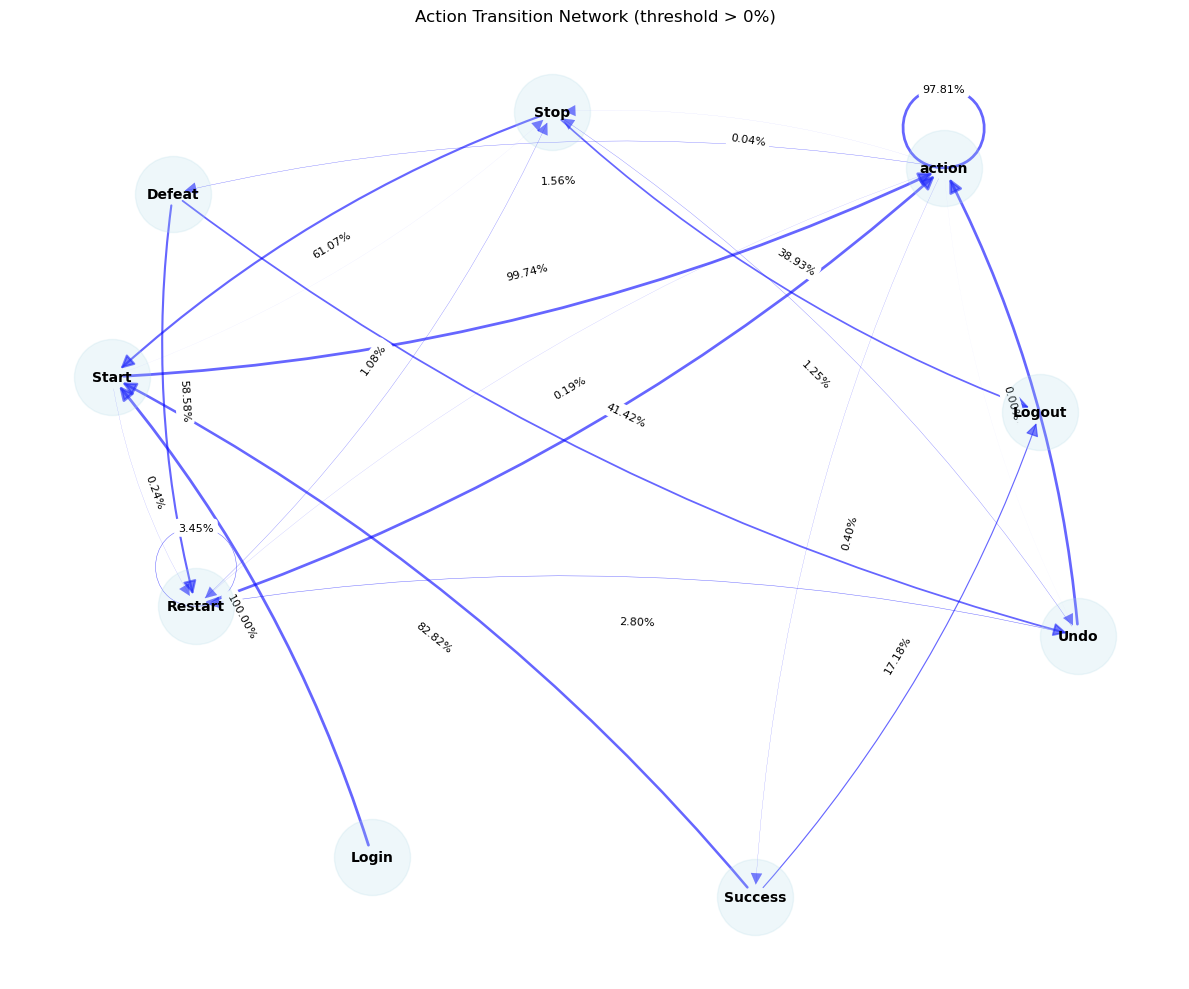

In [39]:
def highest_level(action):
    if action in move_action:
        return 'action'
    return action
level0 = full_df[['Action_Before','Action','Action_After']].map(highest_level)
level0['Before'] = full_df.Before
ratio0 = level0.groupby('Action')['Action_After'].value_counts(normalize=True)
transition_matrix(ratio0, 0)

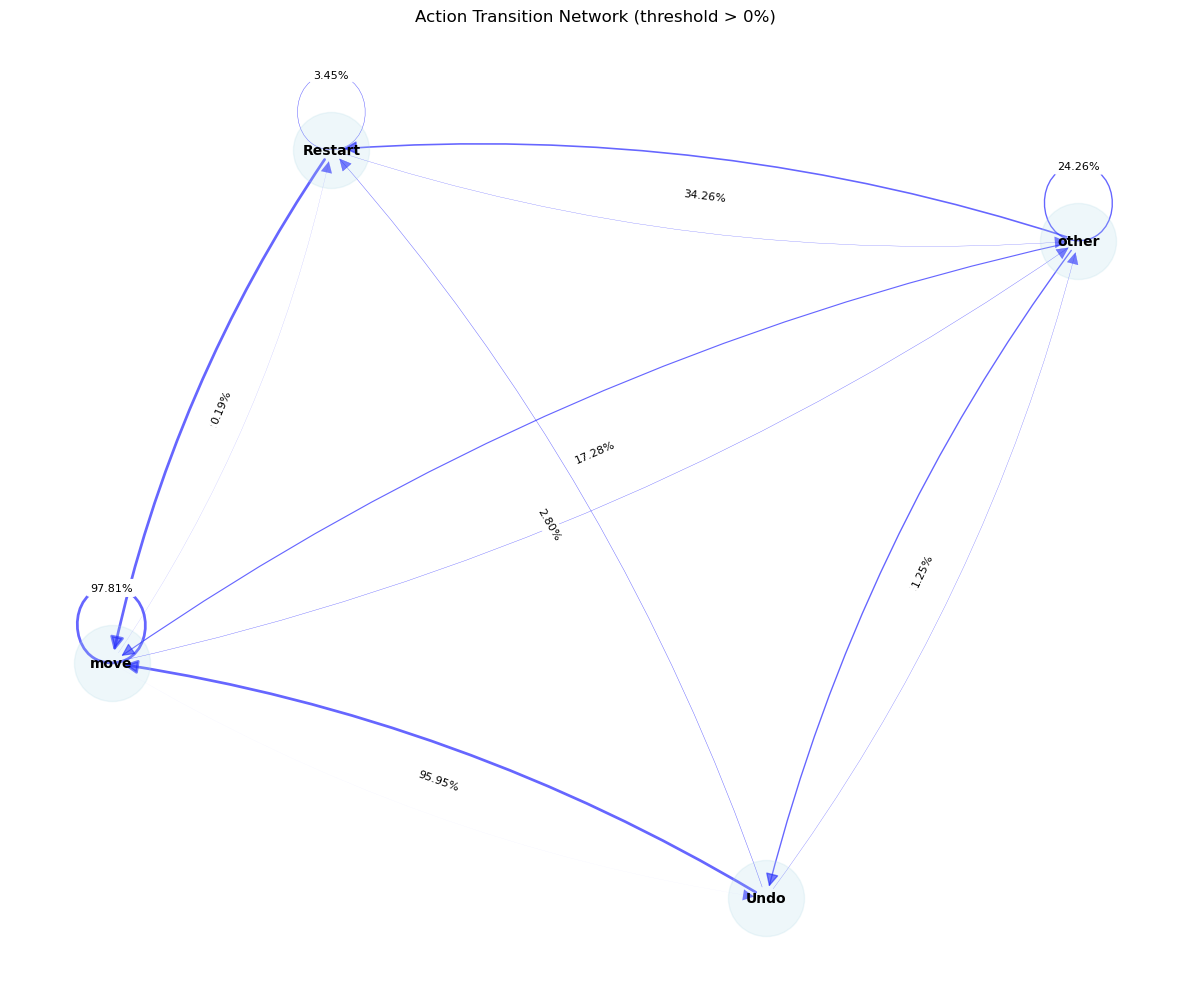

In [ ]:
def first_level(action):
    if action in in_game_action:
        if action in move_action:
            return 'move'
        return action
    return 'other'
level1 = full_df[['Action_Before','Action','Action_After']].map(first_level)
level1['Before'] = full_df.Before
ratio1= level1.groupby('Action')['Action_After'].value_counts(normalize=True)
transition_matrix(ratio1, 0)

In [461]:
def action_relation(row, first, second):
    a1, a2 = row[first], row[second]
    opposite = {'Up': 'Down', 'Down': 'Up', 'Left': 'Right', 'Right': 'Left'}

    if a2 not in move_action:
        return a2
    if a1 not in move_action:
        return 'Move'
    if a1 == a2:
        return 'Same'
    elif a1 == opposite[a2]:
        return 'Oppo'
    else:
        return 'Diff'

AoI.loc[:, 'Action_Before_'] = AoI.apply(lambda row: action_relation(row, 'Action', 'Action_Before'), axis=1)
AoI.loc[:, 'Action_After_'] = AoI.apply(lambda row: action_relation(row, 'Action', 'Action_After'), axis=1)

C:\Users\asus\AppData\Local\Temp\ipykernel_17172\552578133.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  AoI.loc[:, 'Action_Before_'] = AoI.apply(lambda row: action_relation(row, 'Action', 'Action_Before'), axis=1)
C:\Users\asus\AppData\Local\Temp\ipykernel_17172\552578133.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  AoI.loc[:, 'Action_After_'] = AoI.apply(lambda row: action_relation(row, 'Action', 'Action_After'), axis=1)


In [458]:
full_df.Action.value_counts().sort_values()

Action
Stop          804
Login        1240
Logout       1240
Success      5396
Start        6200
Undo         8714
Restart     15573
Defeat      20901
Down       308188
Up         312375
Left       344857
Right      375095
Name: count, dtype: int64

In [459]:
full_df.query("Action == 'Down'").groupby('Action_After').Before.agg(['count', 'mean', 'median']).sort_values('mean')

,count,mean,median
Action_After,,,
Success,1164,0.437711,0.3160
Right,51656,0.506728,0.3000
Left,55296,0.511091,0.2670
Down,186715,0.532585,0.2664
Restart,555,0.577997,0.2666
Defeat,599,0.770974,0.3542
Up,12081,0.832842,0.2840
Stop,122,1.274352,0.2665


In [463]:
from numpy import median
# AoI.query("Action in @move_action").groupby('Action_Before_').Before.agg(['count', 'mean', 'median']).sort_values('mean')
AoI.query("Action in @move_action").groupby('Action_After_').Before.agg(['count', 'mean', 'median']).sort_values('mean')
# AoI.query("Action == 'Undo'").groupby('Action_Before_').Before.agg(['count', 'mean', 'median']).sort_values('median')
# AoI.query("Action == 'Restart'").groupby('Action_After_').Before.agg(['count', 'mean', 'median']).sort_values('median')


,count,mean,median
Action_After_,,,
Undo,56,0.371964,0.266
Success,5029,0.482568,0.317
Diff,372320,0.496016,0.280
Same,762749,0.513796,0.266
Restart,2316,0.608276,0.267
Defeat,18753,0.642044,0.283
Oppo,53669,0.679592,0.273
Stop,370,1.704776,0.267


### HMM分类（一维）

#### main function

In [1]:
class EM_HMM:
    def __init__(self, num_states = 4, data = 'linear', llik = 'ig', init_para = None, ):
        self.num_states = num_states
        self.init_para = self._set_para(init_para)
        self.para = self._set_para(init_para)
        self.data_func = self._data_func(data)
        self.llik_func = self._llik_func(llik)
        self.updata_func = self._updata_func(llik)
    
    def reset_para(self):
        self.para = self.init_para
    
    @staticmethod
    def _data_func(data):
        def trans_linear(rt_series):
            return (np.array(rt_series - 0.25)).clip(1e-6, np.inf)
        
        def trans_log(rt_series):
            return np.log(4 * np.array(rt_series).clip(0.25, np.inf))
        return trans_linear if data == 'linear' else trans_log
    
    @staticmethod
    def _llik_func(llik):

        def logp_ig(x, mu, lam):
            x[x<1e-6], mu_b, lam_b, x_b = 1e-6, mu[np.newaxis, :], lam[np.newaxis, :], x[:, np.newaxis]
            return 0.5 * np.log(lam_b) - 0.5 * np.log(2 * np.pi) - 1.5 * np.log(x_b) - (lam_b * (x_b - mu_b)**2) / (2 * x_b * mu_b**2)
        
        def logp_norm(x, mu, lam):
            x[x<1e-6], mu_b, lam_b, x_b = 1e-6, mu[np.newaxis, :], lam[np.newaxis, :], x[:, np.newaxis]
            return 0.5 * np.log(lam_b) - 0.5 * np.log(2 * np.pi) - 0.5 * lam_b * (x_b - mu_b) ** 2
        
        return logp_ig if llik == 'ig' else logp_norm
    
    @staticmethod
    def _updata_func(llik):

        def update_ig(rt_star, gamma, mu_old, lam_old):
            N_k = gamma.sum(0)
            mu_new = np.where(N_k > 1e-6, gamma.T @ rt_star / N_k, mu_old)
            inv_lam_new = (gamma.T @ (1.0 / rt_star) / N_k) - (1.0 / mu_new)
            lam_new = np.where(inv_lam_new > 1e-6, 1.0 / inv_lam_new, lam_old)
            return mu_new, lam_new

        def update_norm(rt_star, gamma, mu_old, lam_old):
            N_k = gamma.sum(0)
            mu_new = np.where(N_k > 1e-6, gamma.T @ rt_star / N_k, mu_old)
            
            diff_sq = (rt_star[:, np.newaxis] - mu_new[np.newaxis])**2
            lam_new = np.where(N_k > 1e-6, N_k / (gamma * diff_sq).sum(0), lam_old)
            return mu_new, lam_new
        
        return update_ig if llik == 'ig' else update_norm

    def _set_para(self, params = None):
        if params is None:
            A = np.stack([[0.6, 0, 0.4], [0, 0, 1], [0.3, 0.3, 0.4]])
            pi = np.array([0.0, 1.0, 0.0])
            mu_ig = np.array([50.0, 1500.0, 300.0]) * 0.001
            lam_ig = np.array([50.0, 50.0, 50.0]) * 0.001
            params = (A, pi, mu_ig, lam_ig)
        return params
    
    def estep(self, rt_star):
        A, pi, mu_ig, lam_ig = self.para
        T = len(rt_star)
        log_ep = self.llik_func(rt_star, mu_ig, lam_ig)
        log_A = np.log(np.maximum(A, 1e-300))
        log_pi = np.log(np.maximum(pi, 1e-300))

        log_alpha = np.zeros((T, self.num_states))
        log_alpha[0, :] = log_pi + log_ep[0]
        for t in range(1, T):
            log_alpha[t] = log_ep[t] + logsumexp(log_alpha[t-1].reshape(-1, 1) + log_A, axis = 0)
        log_likelihood = logsumexp(log_alpha[T-1])
        log_beta = np.zeros((T, self.num_states))
        for t in range(T-2, -1, -1):
            log_beta[t] = logsumexp(log_A + log_ep[t+1] + log_beta[t+1], axis = 1)
        log_gamma = log_alpha + log_beta - log_likelihood
        gamma = np.exp(log_gamma).clip(1e-10, np.inf)
        log_xi = np.zeros((T-1, self.num_states, self.num_states))
        for t in range(T-1):
            log_xi[t] = log_alpha[t].reshape(-1, 1) + log_A + log_ep[t+1] + log_beta[t+1] - log_likelihood
        xi = np.exp(log_xi).clip(1e-10, np.inf)
        return gamma, xi, log_likelihood

    def mstep(self, rt_star, gamma, xi):
        A_old, pi, mu_old, lam_old = self.para
        gamma_sum, A_new = gamma[:-1].sum(0), np.zeros_like(A_old)
        A_new = np.where(gamma_sum > 1e-6, xi.sum(0) / gamma_sum, A_old)
        A_new[2, 1], A_new[1, 2], A_new[0, 2], A_new[3, 1] = 1e-6, 1e-6, 1e-6, 1e-6
        A_new /= A_new.sum(1, keepdims=True)
        mu_new, lam_new = self.updata_func(rt_star, gamma, mu_old, lam_old)
        return A_new, pi, mu_new, lam_new


    def __call__(self, rt_series, max_iter=1000, tolerance=1e-6):
        rt_series = self.data_func(rt_series)
        log_likelihoods = []
        self.reset_para()

        for i in range(max_iter):
            gamma, xi, ll = self.estep(rt_series)
            log_likelihoods.append(ll)
            if i > 0 and (log_likelihoods[-1] - log_likelihoods[-2]) < tolerance:
                # print(f"EM 算法在第 {i+1} 步收敛。")
                break
            self.para = self.mstep(rt_series, gamma, xi)
        final_gamma, _, _ = self.estep(rt_series)
        pred = final_gamma.argmax(1)
        return self.para, log_likelihoods, final_gamma, pred

def single_step_rt_with_pred(uid, map, steps, pred = None, ax = None):
    ax = ax if ax else plt.subplots(1, 1, figsize = (max(steps // 8, 20), 3))[1]
    selected = AoI.query('Uid == @uid and Map == @map and Count <= @steps')
    ax.plot(np.arange(len(selected)), selected.Before_, alpha = 0.2)
    if 'pred_weighted' not in selected.columns:
        para, _, gamma, pred = hmm_em(selected.Before)
        pred = gamma @ np.array([0, 1, 1, 2]).reshape(-1, 1)
    else:
        pred = selected.pred_weighted
    scatter = ax.scatter(np.arange(len(selected)), selected.Before_, c=pred)
    cbar = plt.colorbar(scatter, ax=ax, shrink = 0.9, aspect = 20)
    cbar.set_label('Cog State')
    cbar.set_ticks([0, 1, 2])
    cbar.set_ticklabels(['Execute', 'Moderate', 'DeepPlan'])
    outcome = 'won' if selected.Action.iloc[-1] == 'Success' else 'lost'
    ax.set(xlabel = '# of Step', ylabel = 'reaction time (s)', title = f'Sub{uid} {outcome} on {map} map', #yscale = 'log',
            xticks = np.arange(len(selected)), xticklabels = [f"{a}\n{c}"if c % 5 == 0 else f"{a}" for c, a in enumerate(selected.Act)])

#### group fitting 

NameError: name 'AoI' is not defined

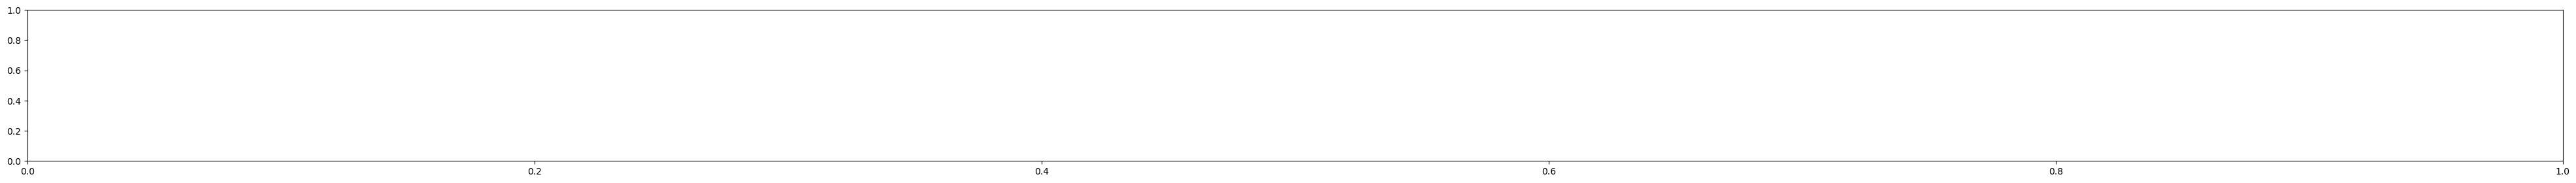

: 

In [ ]:
init_para = (
    np.array([[0.5, 0.4, 0.0, 0.1], [0.3, 0.4, 0, 0.3], [0.5, 0.0, 0.4, 0.1], [0.1, 0.0, 0.6, 0.3]]), # A
    np.array([0.0, 0.0, 0.0, 1]), # pi
    np.array([0.0, 1, 1, 2]), #mu
    np.array([4.0, 2.0, 2.0, 1.0])
)

hmm_em = EM_HMM(data = 'log', llik = 'norm', init_para = init_para)
para = single_step_rt_with_pred(13, 'base', 400)

In [ ]:
## 数据拟合过程
# result_list, param_dict = [], {}
# groups = AoI.groupby(['Uid', 'Map'])
# total = len(groups)

# print(f"开始拟合 {total} 组数据（单核）")

# for i, ((uid, map_name), group) in enumerate(groups):
#     try:
#         para, log_liks, gamma, pred = hmm_em(group.Before_)
#         pred_trans = 2 - gamma @ np.array([0, 1, 1, 2]).reshape(-1, 1)
        
#         group_with_pred = group.copy()
#         group_with_pred['pred_maximum'] = pred
#         group_with_pred['pred_weighted'] = pred_trans
        
#         for k in range(gamma.shape[1]):
#             group_with_pred[f'pred_state_{k}'] = gamma[:, k]
        
#         param = np.vstack([para[0], para[2], para[3]])
#         param_dict[(uid, map_name)] = param
#         result_list.append(group_with_pred)
        
#         # 每10组打印一次进度
#         if (i + 1) % 10 == 0:
#             print(f"已完成 {i+1}/{total} ({(i+1)/total*100:.1f}%)")
    
#     except Exception as e:
#         print(f"警告: Uid={uid}, Map={map_name} 拟合失败: {e}")
#         continue

# result_df = pd.concat(result_list, ignore_index=True)
# print(f"\n完成！成功拟合 {len(result_list)}/{total} 组数据")

开始拟合 5590 组数据（单核）


KeyboardInterrupt: 

In [ ]:
## 数据拟合过程（续）
# cols_to_round = ['pred_weighted', 'pred_state_0', 'pred_state_1', 'pred_state_2', 'pred_state_3']
# # 保留三位小数
# result_df[cols_to_round] = result_df[cols_to_round].round(3)
# # 查看结果
# result_df[cols_to_round].head()
# result_df['pred_weighted'] = 2 - result_df['pred_weighted']
# result_df.to_csv('all_action_rt_hmm.csv')

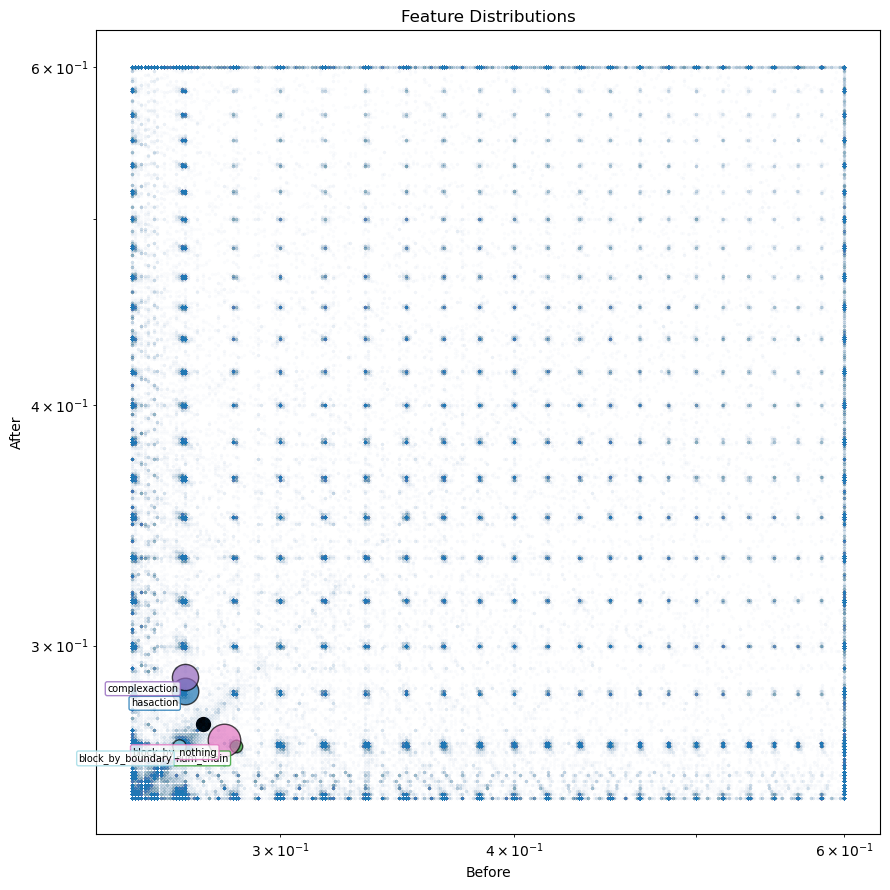

In [324]:
import matplotlib.pyplot as plt

import numpy as np

# 计算统计量
feature_cols = [col for col in cols if col.startswith('inter_') and not col.endswith('_inter')]
fig, ax = plt.subplots(figsize=(9, 9))
colors = plt.cm.tab20(np.linspace(0, 1, len(feature_cols)))
ax.scatter(hmm_base.Before_.median(), hmm_base.After_.median(), s = 100, color = 'black', alpha = 1)
ax.scatter(hmm_base.Before_.clip(0, 0.6), hmm_base.After_.clip(0, 0.6), alpha = 0.01, s = 3)
points, labels = [], []
for i, col in enumerate(feature_cols):
    subset = hmm_base[hmm_base[col] == 1]
    if len(subset) > 10:  # 至少10个样本
        mean_x = subset['Before_'].median()
        mean_y = subset['After_'].median()
        std_x = subset['Before_'].std()
        std_y = subset['After_'].std()
        count = len(subset)
        ax.scatter(mean_x, mean_y, s=np.sqrt(count), color=colors[i], alpha=0.7, 
                  edgecolors='black', linewidth=1)
        label = col.replace('inter_', '').replace('_inter', '').replace('indirect', 'I').replace('direct', 'D')

        ha, va, xytext = 'right', 'top', (-5, -5)
        
        ax.annotate(label, 
                   xy=(mean_x, mean_y),
                   xytext=xytext,
                   textcoords='offset points',
                   fontsize=7,
                   ha=ha, va=va,
                   bbox=dict(boxstyle='round,pad=0.2', 
                            facecolor='white', 
                            alpha=0.8,
                            edgecolor=colors[i]))


ax.set(yscale = 'log', xscale = 'log', xlabel = 'Before', ylabel = 'After', title = 'Feature Distributions')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [84]:
param_rows = []
for (uid, map), param in param_dict.items():
    param = param.flatten()
    row = {'Uid': uid, 'Map': map}
    for i in range(4):
        for j in range(4):
            row[f'A_{i}_{j}'] = param[i * 4 + j]
    for k in range(4):
        row[f'mu_{k}'] = param[16+k]
        row[f'lam_{k}'] = param[20+k]
        row[f'sigma_{k}'] = 1 / np.sqrt(param[20+k])
    param_rows.append(row)
param_df = pd.DataFrame(param_rows)
param_df.to_csv('all_subject_hmm_param.csv', index=False)


#### 分析一下拟合后的结果

In [3]:
hmm_df = pd.read_csv('all_action_rt_ana_3.csv')
# sub_df = pd.read_csv('all_subject_hmm_param.csv')

In [50]:
A_col = sub_df[[col for col in sub_df.columns if 'A' in col]]
mu_col = sub_df[[col for col in sub_df.columns if 'mu' in col]]
sigma_col = sub_df[[col for col in sub_df.columns if 'sigma' in col]]

In [58]:
A_col.groupby(sub_df.Map).mean()

,A_0_0,A_0_1,A_0_2,A_0_3,A_1_0,A_1_1,A_1_2,A_1_3,A_2_0,A_2_1,A_2_2,A_2_3,A_3_0,A_3_1,A_3_2,A_3_3
Map,,,,,,,,,,,,,,,,
base,0.415522,0.366588,7.440355e-07,0.217889,0.254482,0.563179,0.000001,0.182338,0.140562,0.000001,0.674443,0.184993,0.117892,0.000001,0.515063,0.367044
break,0.407717,0.362406,6.594104e-07,0.229876,0.253056,0.540660,0.000001,0.206282,0.114736,0.000001,0.678218,0.207044,0.105933,0.000001,0.600188,0.293878
helper,0.398146,0.406345,7.432916e-07,0.195508,0.298117,0.507558,0.000001,0.194324,0.179757,0.000001,0.613459,0.206783,0.111560,0.000001,0.587923,0.300516
intro,0.293597,0.622358,9.050195e-07,0.084044,0.455613,0.364929,0.000894,0.178564,0.466291,0.001776,0.395385,0.136548,0.137886,0.000001,0.770760,0.091353
make,0.417950,0.364599,6.763934e-07,0.217451,0.273685,0.528118,0.000001,0.198196,0.100354,0.000001,0.706391,0.193254,0.086795,0.000001,0.528997,0.384207
maze,0.399270,0.385231,7.203594e-07,0.215498,0.283996,0.511627,0.000001,0.204376,0.144432,0.000001,0.644710,0.210856,0.113556,0.000001,0.587781,0.298662
target,0.396677,0.328810,6.510109e-07,0.274512,0.236717,0.587888,0.000001,0.175394,0.152356,0.000002,0.734581,0.113062,0.106019,0.000001,0.560651,0.333329
tutorial,0.352228,0.491420,8.289657e-07,0.156351,0.370788,0.449370,0.000001,0.179841,0.431280,0.000002,0.443686,0.125033,0.090895,0.000001,0.752571,0.156532


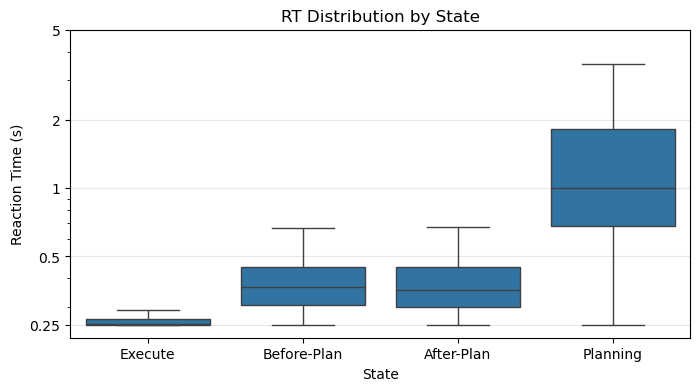

In [62]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=hmm_base, x='pred_maximum', y='Before', showfliers=False, ax=ax)
ax.set(xlabel='State', ylabel='Reaction Time (s)', title = 'RT Distribution by State', yscale = 'log',
       xticks = [0, 1, 2, 3], xticklabels = ['Execute', 'Before-Plan', 'After-Plan', 'Planning'],
       yticks = tick_values[:5], yticklabels = tick_values[:5])
ax.grid(axis='y', alpha=0.3)
plt.show()

In [112]:
cols = [col for col in hmm_df.columns if col.startswith('cha')]
hmm_df[cols].groupby(hmm_df.pred_maximum).mean()

,cha_num_form_rules,cha_num_break_rules,cha_form_rules,cha_break_rules,cha_form_WIN_rule,cha_break_WIN_rule,cha_form_DEFEAT_rule,cha_break_DEFEAT_rule,cha_form_PUSH_rule,cha_break_PUSH_rule,...,cha_create_REGULAR_object,cha_destroy_REGULAR_object,cha_reachable_REGULAR_object,cha_unreachable_REGULAR_object,cha_direct_for_REGULAR_object,cha_direct_approach_REGULAR_object,cha_direct_avoid_REGULAR_object,cha_indirect_for_REGULAR_object,cha_indirect_approach_REGULAR_object,cha_indirect_avoid_REGULAR_object
pred_maximum,,,,,,,,,,,,,,,,,,,,,
0,0.003420,0.011882,0.003419,0.011873,0.000607,0.000152,0.000137,0.000770,0.000442,0.000956,...,0.004871,0.007297,0.003860,0.003572,-0.000348,0.193875,0.065837,-0.000416,0.051146,0.065837
1,0.005472,0.021519,0.005450,0.021505,0.000921,0.000190,0.000292,0.001454,0.000840,0.002279,...,0.011518,0.009618,0.006440,0.004789,0.000582,0.218778,0.072737,0.000926,0.066454,0.072737
2,0.004656,0.020522,0.004635,0.020495,0.000798,0.000210,0.000410,0.001725,0.000711,0.002096,...,0.009420,0.010034,0.006893,0.004408,-0.001100,0.205675,0.074353,-0.000787,0.060347,0.074353
3,0.004369,0.021706,0.004334,0.021685,0.000402,0.000263,0.000838,0.002846,0.000568,0.002402,...,0.012220,0.012774,0.011466,0.004397,0.005802,0.191002,0.060568,0.008879,0.078175,0.060568


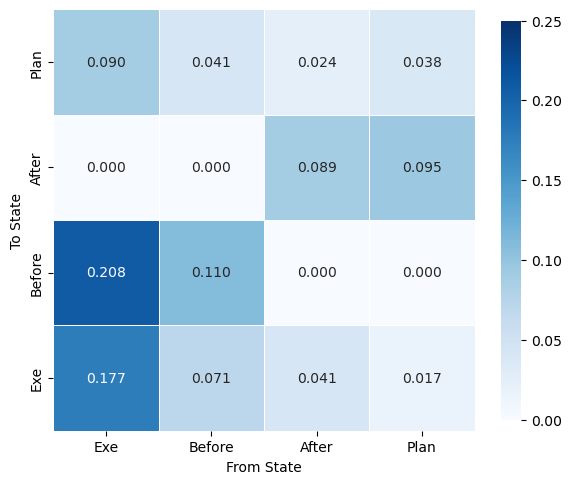

In [155]:
A_mean = sub_df[[col for col in sub_df.columns if 'A' in col]].mean().round(3).to_numpy().reshape(4, 4)
ratio = hmm_df[[col for col in hmm_df.columns if col.startswith('pred_state')]].mean().to_numpy()

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
sns.heatmap(ratio * A_mean.T, annot=True, fmt='.3f', cmap='Blues', 
            vmin=0, vmax=0.25,  # 0=白色, 1=蓝色
            cbar_kws={'shrink':0.7},
            xticklabels=['Exe', 'Before', 'After', 'Plan'],
            yticklabels=['Exe', 'Before', 'After', 'Plan'],
            ax=ax, square=True, linewidths=0.5)
ax.set(xlabel='From State', ylabel='To State')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Feature Engineering

In [3]:
cols = [col for col in hmm_df.columns if col.startswith('cha_') or col.startswith('inter_') or col.startswith('pre_')]
bool_cols = [col for col in cols if hmm_df[col].nunique() <= 2]
len(bool_cols)

99

In [264]:
idx = hmm_df[bool_cols].apply(tuple, axis = 1)

In [275]:
state_by_grid_coord = pd.Series({'base': 131853, 'break': 8472, 'helper': 72869, 'intro': 5434, 
 'make': 2430, 'maze': 6494, 'target': 130771, 'tutorial': 7823})
state_by_predicate = idx.groupby(hmm_df.Map).nunique()

C:\Users\asus\AppData\Local\Temp\ipykernel_31708\3589037073.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.annotate(f'{label}\n({x[i]:.0f}, {y[i]:.0f})',
C:\Users\asus\AppData\Local\Temp\ipykernel_31708\3589037073.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  xy=(x[i], y[i]),


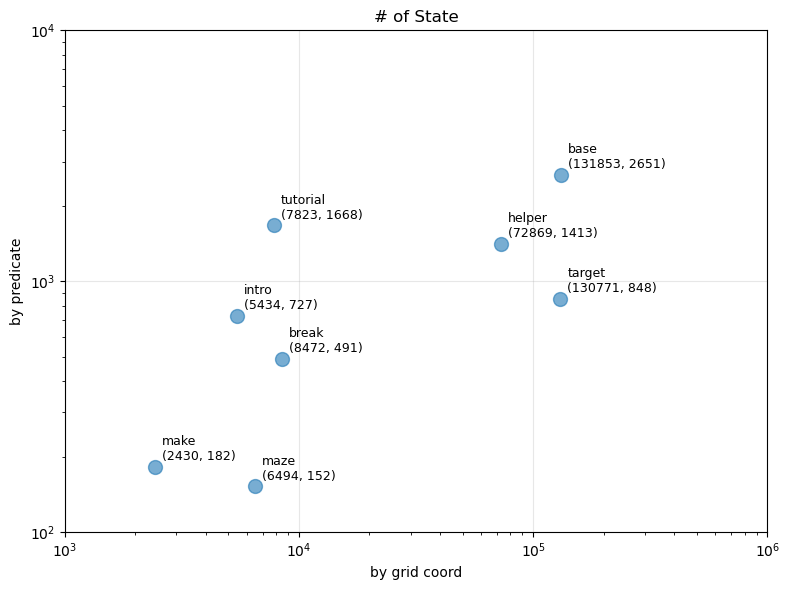

In [283]:
result = pd.concat([state_by_grid_coord, state_by_predicate], axis = 1)
result.columns = ['# of State by grid coord', '# of State by predicate']
fig, ax = plt.subplots(figsize=(8, 6))

# 假设你有x, y坐标和标签
# 例如：result是一个DataFrame，有Count和Unique列，index是Map名称
x = result['# of State by grid coord']
y = result['# of State by predicate']
labels = result.index

# 绘制散点
ax.scatter(x, y, s=100, alpha=0.6)

# 为每个点添加标注
for i, label in enumerate(labels):
    ax.annotate(f'{label}\n({x[i]:.0f}, {y[i]:.0f})',
                xy=(x[i], y[i]),
                xytext=(5, 5),  # 偏移量
                textcoords='offset points',
                fontsize=9,
                ha='left')
ax.set(xscale = 'log', yscale = 'log',xlim = [1000, 1000000], ylim = [100, 10000],
       xlabel = 'by grid coord', ylabel = 'by predicate', title = '# of State')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [288]:
col = 'inter_indirect_REGULAR_inter'
hmm_base.groupby(col)[['LogBefore', 'LogAfter']].count()

,LogBefore,LogAfter
inter_indirect_REGULAR_inter,,
0.0,307444,307444
1.0,2633,2633


In [203]:
hmm_base[col]

0          1.0
1          1.0
2          1.0
3          1.0
4          1.0
          ... 
1259281    0.0
1259282    0.0
1259283    0.0
1259284    0.0
1259285    NaN
Name: pre_exist_DEFEAT_object, Length: 320206, dtype: float64

In [5]:
col = 'pre_exist_DEFEAT_object'
hmm_base = hmm_df.query('Map == "base"')
hmm_base.groupby(col)[['LogBefore', 'LogAfter']].sum()

,LogBefore,LogAfter
pre_exist_DEFEAT_object,,
0.0,6381.125673,5241.486995
1.0,113703.505622,105775.393549


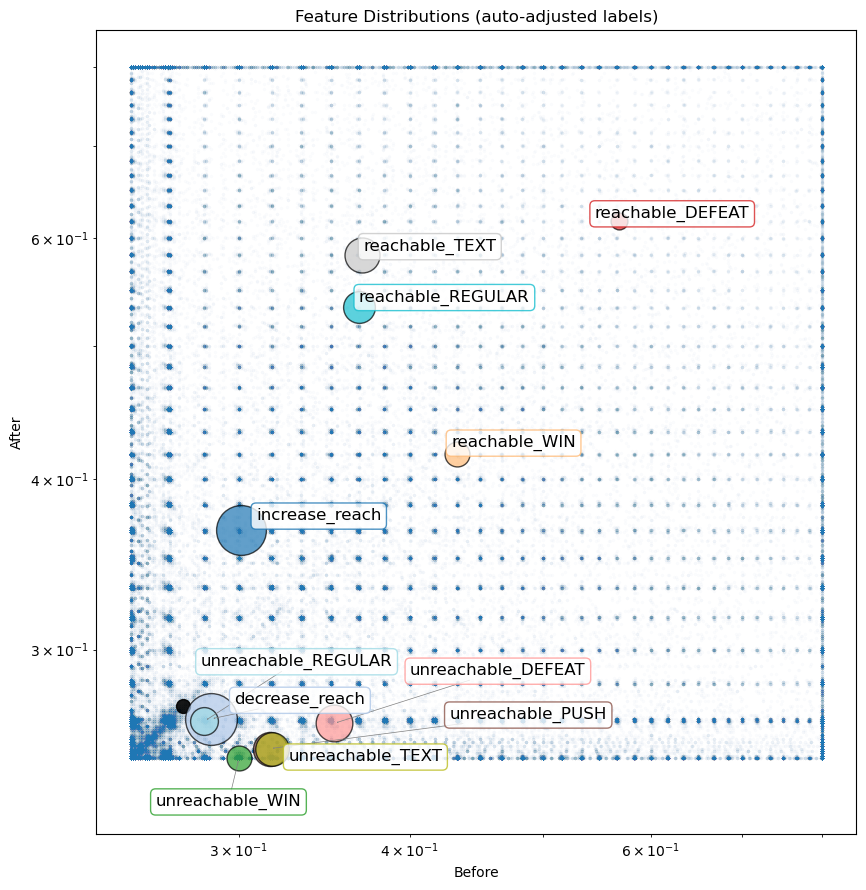

In [33]:

feature_cols = [col for col in bool_cols if col.startswith('cha_') and 'reach' in col]
fig, ax = plt.subplots(figsize=(12, 9))
colors = plt.cm.tab20(np.linspace(0, 1, len(feature_cols)))

texts = []  # 存储所有文本对象
ax.scatter(hmm_base.Before_.clip(0, 0.8), hmm_base.After_.clip(0, 0.8), alpha = 0.01, s = 3)
ax.scatter(hmm_base.Before_.median(), hmm_base.After_.median(), alpha = 0.9, c='black', s = 100)
for i, col in enumerate(feature_cols):
    subset = hmm_base[hmm_base[col] == 1]
    if len(subset) > 10:
        mean_x = subset['Before_'].median()
        mean_y = subset['After_'].median()
        
        # 绘制散点
        ax.scatter(mean_x, mean_y, s=np.sqrt(len(subset)) * 10, color=colors[i], alpha=0.7, 
                  edgecolors='black', linewidth=1)
        
        # 添加文本
        label = col.replace('cha_', '').replace('_objects', '').replace('_object', '')
        txt = ax.text(mean_x, mean_y, label, fontsize=12, 
                     bbox=dict(boxstyle='round,pad=0.3', 
                              facecolor='white', 
                              alpha=0.8,
                              edgecolor=colors[i]))
        texts.append(txt)

# 自动调整文本位置避免重叠
adjust_text(texts, 
           arrowprops=dict(arrowstyle='->', color='gray', lw=0.5),
           ax=ax)

ax.set(yscale='log', xscale='log', xlabel='Before', ylabel='After', aspect = 'equal',
       title='Feature Distributions (auto-adjusted labels)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
x = [3]
x[2:]

[]

In [29]:
def select(map, start, median = ''):
    df = hmm_df[hmm_df.Map == map]
    cols = [col for col in df.columns if col.startswith(start) and median in col]
    full_cols = ['Uid','Count', 'Act', 'Outcome'] + cols
    return df[full_cols].copy(), cols
def idxtodes_interaction(row):
    direct, indirect = [], []
    for col in cols:
        if col.startswith('inter_'):
            if row[col] == 1 and '_direct' in col:
                direct.append(col.split('_')[3])
            elif row[col] == 1 and '_indirect' in col:
                indirect.append(col.split('_')[3])
    lines = "You"
    lines += f"->[{','.join(direct)}]" if direct else ''
    lines += f"->[{','.join(indirect)}]" if indirect else ''
    return lines

def idxtodes_rule(row):
    dic = {'has': [], 'form': [], 'break': []}
    for prop in ['WIN', 'DEFEAT', 'PUSH', 'STOP', 'YOU']:
        if row[f'pre_bool_has_{prop}_rule'] == 1:
            dic['has'].append(prop)
        if row[f'cha_bool_form_{prop}_rule'] == 1:
            dic['form'].append(prop)
        if row[f'cha_bool_break_{prop}_rule'] == 1:
            dic['break'].append(prop)
    lines = f"[{','.join(dic['has'])}]"
    if dic['form']:
        lines += f" + [{','.join(dic['form'])}]"
    if dic['break']:
        lines += f" - [{','.join(dic['break'])}]"
    return lines

def idxtodes_object(row):
    man = {'reach': 'pre_bool_man_exist', 'reachable': 'cha_bool_man_reachable', 'unreachable': 'cha_bool_man_unreachable'}
    game = {'reach': 'pre_bool_game_reach', 'reachable': 'cha_bool_game_reachable', 'unreachable': 'cha_bool_game_unreachable'}
    manr, gamer = {item: [] for item in man}, {item: [] for item in game}

    for prop in ['WIN', 'DEFEAT', 'PUSH', 'STOP', 'TEXT', 'REGULAR']:
        for item in gamer.keys():
            if row[f'{game[item]}_{prop}_object'] is True:
                gamer[item].append(prop)
            elif row[f'{man[item]}_{prop}_object'] is True:
                manr[item].append(prop)
    lines = f"[{','.join(gamer['reach'])}]"
    # if gamer['reachable']:
    #     lines += f"+[{','.join(gamer['reachable'])}]"
    # if gamer['unreachable']:
    #     lines += f"-[{','.join(gamer['unreachable'])}]"
    lines += f") ([{','.join(manr['reach'])}])"
    # if manr['reachable']:
    #     lines += f"+[{','.join(manr['reachable'])}]"
    # if manr['unreachable']:
    #     lines += f"-[{','.join(manr['unreachable'])}]"
    return lines
        
# df, cols = select('intro', 'inter_', 'direct')
# df.loc[:, 'idx'] = df.apply(idxtodes_interaction, axis = 1)
# df, cols = select('tutorial', '', '_rule')
# df.loc[:, 'idx'] = df.apply(idxtodes_rule, axis = 1)

### Summary of interaction type

In [98]:
## 简单代码判断有没有过关

hmm_df['win_bool_idx'] = hmm_df.Outcome == 'Win'
hmm_df['win_bool_idx'] = hmm_df.groupby(['Uid', 'Map']).win_idx.transform('any')

In [2]:
hmm_df = pd.read_csv('all_action_rt_ana_3.csv')

NameError: name 'pd' is not defined

In [1]:
select('intro', 'pre_', '')


NameError: name 'select' is not defined

In [91]:
data, cols = select('maze', '', '')
data.apply(idxtodes_object, axis = 1).unique()

array(['([STOP,TEXT]) ([WIN]))', '([]) ([]))',
       '([STOP,TEXT]+[WIN]) ([WIN]))', '([WIN,STOP,TEXT]-[WIN]) ([]))',
       '([WIN,STOP,TEXT]) ([]))'], dtype=object)

In [30]:
df = {}
for i, map in enumerate(['intro', 'tutorial', 'base', 'target', 'maze', 'make', 'break', 'helper']):
    df[map], cols = select(map, '', '_bool')
    df[map].loc[:, 'inter_idx'] = df[map].apply(idxtodes_interaction, axis = 1)
    df[map].loc[:, 'rule_idx'] = df[map].apply(idxtodes_rule, axis = 1)
    df[map].loc[:, 'object_idx'] = df[map].apply(idxtodes_object, axis = 1)

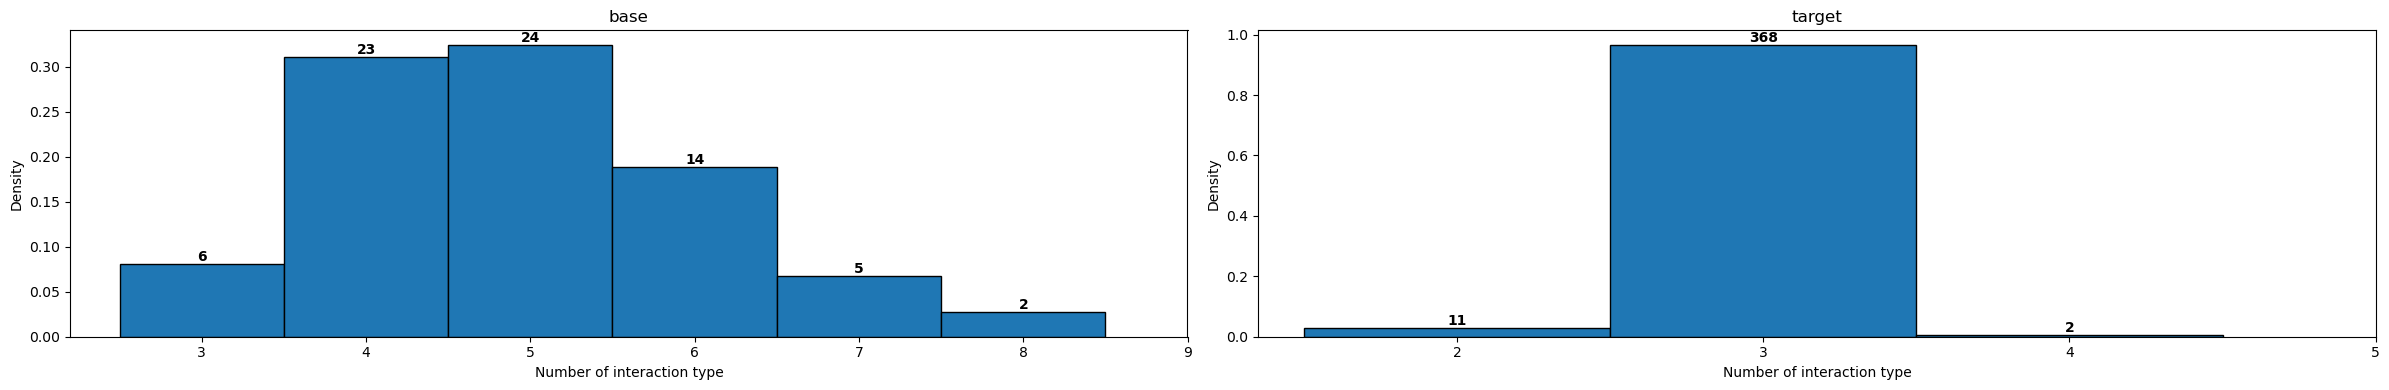

In [165]:
col_of_interest = 'object_idx'
fig, ax = plt.subplots(1, 2, figsize = (24, 4))
ax = ax.flatten()
for i, map in enumerate(['base', 'target']):#, 'maze', 'make', 'break', 'helper']):
    data = df[map][df[map].win_bool_idx == False]
    counts = data.groupby('Uid')[col_of_interest].nunique().value_counts().sort_index()
    xticks = np.arange(counts.index.min(), counts.index.max() + 2)
    data.groupby('Uid')[col_of_interest].nunique().hist(bins = xticks - 0.5, density = True, edgecolor= 'black', ax = ax[i])
    for val, count in counts.items():
        ax[i].text(val, count / len(data.groupby('Uid')), f'{count}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax[i].set(xlabel = 'Number of interaction type', ylabel = 'Density', xticks = xticks, title = map)
        ax[i].grid(False)
plt.tight_layout()

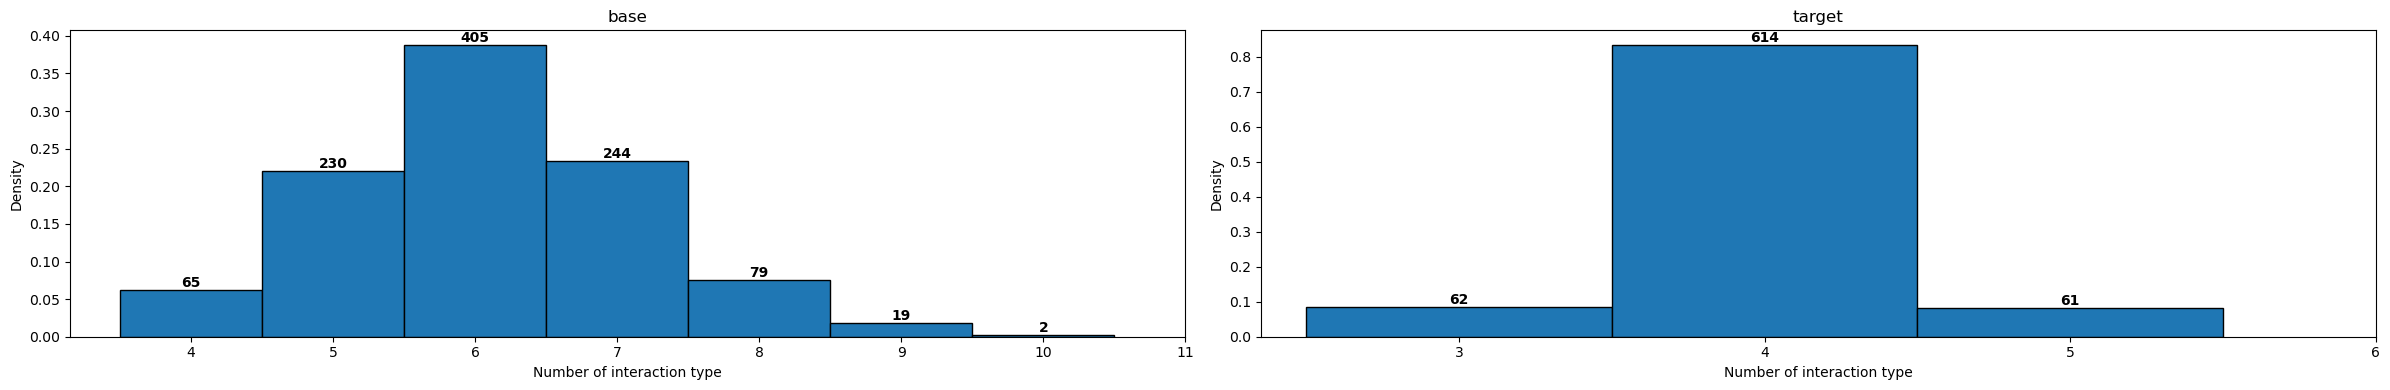

In [166]:
col_of_interest = 'object_idx'
fig, ax = plt.subplots(1, 2, figsize = (24, 4))
ax = ax.flatten()
for i, map in enumerate(['base', 'target']):#, 'maze', 'make', 'break', 'helper']):
    data = df[map][df[map].win_bool_idx == True]
    counts = data.groupby('Uid')[col_of_interest].nunique().value_counts().sort_index()
    xticks = np.arange(counts.index.min(), counts.index.max() + 2)
    data.groupby('Uid')[col_of_interest].nunique().hist(bins = xticks - 0.5, density = True, edgecolor= 'black', ax = ax[i])
    for val, count in counts.items():
        ax[i].text(val, count / len(data.groupby('Uid')), f'{count}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax[i].set(xlabel = 'Number of interaction type', ylabel = 'Density', xticks = xticks, title = map)
        ax[i].grid(False)
plt.tight_layout()

In [149]:
nunique_actions = {}
idx = 'inter_idx'
map = 'tutorial'
data = df[map]#[df[map].win_bool_idx]
summary = data.groupby(['Uid', idx]).Act.any().groupby(idx).sum().sort_values(ascending = False)

(summary/summary.max() * 100).round(1).head(50)

inter_idx
You                                        100.0
You->[PUSH]                                 98.4
You->[WIN]                                  84.7
You->[DEFEAT]                               50.1
You->[PUSH]->[TEXT]                         38.2
You->[PUSH]->[PUSH]                         31.7
You->[TEXT]->[TEXT]                         21.9
You->[PUSH]->[WIN]                          14.4
You->[WIN,PUSH]                             14.0
You->[REGULAR]                               6.3
You->[PUSH]->[PUSH,TEXT]                     4.2
You->[TEXT]                                  3.7
You->[TEXT]->[REGULAR]                       3.7
You->[TEXT]->[PUSH]                          3.0
You->[PUSH]->[DEFEAT]                        2.2
You->[TEXT,REGULAR]                          2.0
You->[TEXT,REGULAR]->[REGULAR]               1.8
You->[TEXT]->[PUSH,REGULAR]                  1.7
You->[REGULAR]->[TEXT,REGULAR]               1.7
You->[TEXT,REGULAR]->[TEXT,REGULAR]          1.6
You->[TEXT

In [111]:
summary

inter_idx
You->[STOP,TEXT]->[TEXT,REGULAR]                 1
You->[TEXT,REGULAR]->[YOU,TEXT,REGULAR]          1
You->[TEXT,REGULAR]->[WIN,TEXT]                  1
You->[TEXT,REGULAR]->[STOP,TEXT]                 1
You->[YOU,TEXT]->[YOU,REGULAR]                   1
You->[YOU,TEXT,REGULAR]->[YOU,REGULAR]           1
You->[YOU,TEXT,REGULAR]->[WIN,TEXT]              1
You->[WIN,YOU,TEXT]->[YOU]                       1
You->[YOU,TEXT]->[YOU,TEXT,REGULAR]              1
You->[WIN,YOU]                                   2
You->[YOU,TEXT,REGULAR]->[YOU,TEXT,REGULAR]      2
You->[YOU,TEXT,REGULAR]->[TEXT,REGULAR]          2
You->[TEXT,REGULAR]->[WIN,TEXT,REGULAR]          2
You->[STOP,TEXT]->[TEXT]                         2
You->[TEXT,REGULAR]->[YOU]                       2
You->[TEXT]->[STOP,TEXT,REGULAR]                 2
You->[YOU,TEXT,REGULAR]->[YOU]                   2
You->[TEXT]->[YOU]                               3
You->[WIN,YOU,TEXT]->[YOU,TEXT]                  3
You->[WIN,TEXT]->[TEX

In [18]:
df['target'][df['target'].idx == 'You->[WIN,TEXT]->[DEFEAT,TEXT]']

,Uid,Count,Act,Outcome,inter_bool_direct_WIN_inter,inter_bool_direct_DEFEAT_inter,inter_bool_direct_PUSH_inter,inter_bool_direct_STOP_inter,inter_bool_direct_YOU_inter,inter_bool_direct_TEXT_inter,inter_bool_direct_REGULAR_inter,inter_bool_indirect_WIN_inter,inter_bool_indirect_DEFEAT_inter,inter_bool_indirect_PUSH_inter,inter_bool_indirect_STOP_inter,inter_bool_indirect_YOU_inter,inter_bool_indirect_TEXT_inter,inter_bool_indirect_REGULAR_inter,idx
907381,977,746,←,Win,True,False,False,False,False,True,False,False,True,False,False,False,True,False,"You->[WIN,TEXT]->[DEFEAT,TEXT]"


#### Summary for rule domain

In [ ]:
# df, cols = select('tutorial', '', '_rule')
# df.loc[:, 'idx'] = df.apply(idxtodes_rule, axis = 1)

### 修复一下defeat/success的bug

In [8]:
import pandas as pd
import numpy as np
cols = ['Pid','Uid','Prior','Cond','Level','Map','Count_Global','Count','Timestamp','Action','Action_Before','Action_After','Before','After','Act','Outcome',
    'pred_maximum','pred_weighted','pred_state_0','pred_state_1','pred_state_2','pred_state_3']
df = pd.read_csv('all_action_rt_hmm.csv', usecols = cols)

In [9]:

df = df.query('Action != "Defeat"')
df['Before'] = df['Timestamp'] - df.groupby('Uid')['Timestamp'].shift(1)
df['After'] = df.groupby('Uid')['Timestamp'].shift(-1) - df['Timestamp']
df['Action_Before'] = df.groupby('Uid')['Action'].shift(1)
df['Action_After'] = df.groupby('Uid')['Action'].shift(-1)
df = df.query('Action in @game_action').reset_index(drop=True)
df.loc[df['Action_After'] == 'Success', 'After'] = np.nan
df['Count'] = df.groupby(['Uid', 'Map']).cumcount()
df.to_csv('game_action_rt_with_hmm_pred.csv', index = False)

## 预测模型新纪元

In [2]:
hmm_df = pd.read_csv('all_action_rt_ana_3.csv')


In [3]:
def select(map, start, median = ''):
    df = hmm_df[hmm_df.Map == map]
    cols = [col for col in df.columns if col.startswith(start) and median in col]
    full_cols = ['Uid', 'Count', 'Action', 'Act', 'Outcome'] + cols
    return df[full_cols].copy(), cols

test_data = select('intro', 'inter_', 'interaction')[0].head(20)

In [10]:
from gridMap import Gridmap
Gridmap.state_index['15a7e8072e44b0ab']

{'state_key': '15a7e8072e44b0ab',
 'info': {'num_rule': 4,
  'rules': ['STOP', 'WIN', 'YOU', 'PUSH'],
  'you': (11, 6),
  'num_object': 39,
  'man_dist': [0, inf, 2, 2, 3, inf],
  'num_reachable': 38,
  'game_dist': [0, inf, 2, 2, 7, inf]},
 'inter': {'num_inter': 62,
  'inters': ['15a7e8072e44b0ab_up_11_8',
   '15a7e8072e44b0ab_left_10_7',
   '15a7e8072e44b0ab_down_11_4',
   '15a7e8072e44b0ab_up_10_7',
   '15a7e8072e44b0ab_up_12_8',
   '15a7e8072e44b0ab_down_10_4',
   '15a7e8072e44b0ab_down_12_4',
   '15a7e8072e44b0ab_left_8_6',
   '15a7e8072e44b0ab_up_13_8',
   '15a7e8072e44b0ab_down_9_4',
   '15a7e8072e44b0ab_left_8_5',
   '15a7e8072e44b0ab_down_13_4',
   '15a7e8072e44b0ab_up_9_8',
   '15a7e8072e44b0ab_right_10_7',
   '15a7e8072e44b0ab_up_8_8',
   '15a7e8072e44b0ab_down_8_6',
   '15a7e8072e44b0ab_left_13_8',
   '15a7e8072e44b0ab_left_13_4',
   '15a7e8072e44b0ab_up_7_8',
   '15a7e8072e44b0ab_left_13_9',
   '15a7e8072e44b0ab_left_13_3',
   '15a7e8072e44b0ab_right_8_6',
   '15a7e8072e4

In [4]:
from recorder import simulate_actions_to_states
simulate_actions_to_states(test_data, 'intro', '.')

,Uid,Count,Action,Act,Outcome,inter_bool_interaction,pre_state,post_state
0,110,0,Right,→,Continue,False,6f48749412f4570a,868f51d5958793b1
1,110,1,Down,↓,Continue,False,868f51d5958793b1,d9aa27b6ff4c244f
2,110,2,Right,→,Continue,False,d9aa27b6ff4c244f,a34fd869d3f48672
3,110,3,Right,→,Continue,True,a34fd869d3f48672,e85c8cdda085da5e
4,110,4,Right,→,Continue,True,e85c8cdda085da5e,4aa57e377874b6b7
5,110,5,Up,↑,Continue,False,4aa57e377874b6b7,c44e243e4e3586c4
6,110,6,Right,→,Continue,False,c44e243e4e3586c4,6313d56bc811a703
7,110,7,Right,→,Win,True,6313d56bc811a703,0ef0876fda446a41
8,111,0,Restart,↻,Continue,NaN,6f48749412f4570a,6f48749412f4570a
9,111,1,Restart,↻,Continue,NaN,6f48749412f4570a,6f48749412f4570a


In [38]:
intro = df['intro']
intro_inter = intro.query("inter_bool_interaction == True")
intro_inter_count = intro_inter.groupby('Uid').Act.count()
# intro_inter_count.sort_values()
intro_inter_first = intro_inter.groupby('Uid').first()
intro_inter_first.groupby('inter_idx').Act.count()

inter_idx
You->[PUSH]            857
You->[STOP]            229
You->[TEXT]->[STOP]      4
You->[TEXT]->[TEXT]     10
You->[WIN]              18
Name: Act, dtype: int64